<a href="https://colab.research.google.com/github/IvyOfomata/Foundations-of-AI-Project--Food_HUB/blob/main/Pandas_for_Data_Science_Food_Hub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Context**

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

**Objective**

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Perform the data analysis to find answers to these questions that will help the company to improve the business.



**Data Dictionary**

order_id: Unique ID of the order

customer_id: ID of the customer who ordered the food

restaurant_name: Name of the restaurant

cuisine_type: Cuisine ordered by the customer

cost: Cost of the order

day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)

rating: Rating given by the customer out of 5

food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.

delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

In [ ]:
# importing the libraries
import numpy as np
import pandas as pd

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#load dataset
foodhub_order = pd.read_csv('/content/drive/MyDrive/foodhub_order (2).csv')


Mounted at /content/drive


In [ ]:
# make a copy of data
df = foodhub_order.copy()
print(df.head())



   order_id  customer_id            restaurant_name cuisine_type  \
0   1477147       337525                    Hangawi       Korean   
1   1477685       358141  Blue Ribbon Sushi Izakaya     Japanese   
2   1477070        66393                Cafe Habana      Mexican   
3   1477334       106968  Blue Ribbon Fried Chicken     American   
4   1478249        76942           Dirty Bird to Go     American   

   cost_of_the_order day_of_the_week     rating  food_preparation_time  \
0              30.75         Weekend  Not given                     25   
1              12.08         Weekend  Not given                     25   
2              12.23         Weekday          5                     23   
3              29.20         Weekend          3                     25   
4              11.59         Weekday          4                     25   

   delivery_time  
0             20  
1             23  
2             28  
3             15  
4             24  


In [ ]:
print(df.tail())
print(df.shape)
print(df.info())


      order_id  customer_id                        restaurant_name  \
1893   1476701       292602  Chipotle Mexican Grill $1.99 Delivery   
1894   1477421       397537                              The Smile   
1895   1477819        35309                      Blue Ribbon Sushi   
1896   1477513        64151                      Jack's Wife Freda   
1897   1478056       120353                      Blue Ribbon Sushi   

       cuisine_type  cost_of_the_order day_of_the_week     rating  \
1893        Mexican              22.31         Weekend          5   
1894       American              12.18         Weekend          5   
1895       Japanese              25.22         Weekday  Not given   
1896  Mediterranean              12.18         Weekday          5   
1897       Japanese              19.45         Weekend  Not given   

      food_preparation_time  delivery_time  
1893                     31             17  
1894                     31             19  
1895                     31  

**Observations:**



*   Perfect Data Quality: Every single column has 1,898 non-null entries, which means there is no missing information in the entire dataset.

*   Clean Data Types: The data is stored correctly, with numbers (integers/floats) for costs and times, and text (objects) for names and cuisines.






*  Ready for Analysis: Since the "Non-Null Count" matches the number of entries for every row, you don't need to perform any data cleaning or "filling in the blanks" before moving to your charts.






In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


**Observations:**



*  Consistent Order Costs: The average meal costs about $16.50, but most people spend between $12 and $22.

*  Standard Prep Times: Restaurants are very consistent, taking between 20 and 35 minutes to get food ready for delivery.


*   Fast Delivery Window: Once the food is picked up, it usually takes about 24 minutes to reach the customer's door.

*   Predictable Total Experience: From start to finish, the process is very stable with no extreme outliers, meaning customers can generally expect their food within an hour.










In [ ]:
df.describe(exclude='number').T

,count,unique,top,freq
restaurant_name,1898,178,Shake Shack,219
cuisine_type,1898,14,American,584
day_of_the_week,1898,2,Weekend,1351
rating,1898,4,Not given,736


**Observations**:

*   Heavy Reliance on One Partner: Shake Shack is the top restaurant with 219 orders, showing that a single brand drives over 11% of your total business.

*  Strong Preference for American Food: With 584 orders, American cuisine is the most popular of the 14 types and is the primary driver of platform volume.





*   Major Weekend Demand: Over 71% of orders happen on the weekend, meaning the platform is mostly used for leisure rather than daily weekday meals.
*   Large Gap in Customer Feedback: Nearly 39% of orders are marked as "Not given" for ratings, leaving the company with a significant blind spot regarding customer satisfaction.







In [ ]:
#Exploratory numerical variables
import matplotlib.pyplot as plt
import seaborn as sns

def histogram_boxplot(feature, figsize=(15,10), bins="auto"):
  f,(ax_box,ax_hist) = plt.subplots(nrows=2,sharex = True, gridspec_kw={"height_ratios":(0.25,0.75)},figsize=figsize)
  sns.boxplot(x=feature,ax=ax_box, showmeans=True, color="violet",width=0.5)
  sns.histplot(x=feature, kde=False, bins=bins, ax=ax_hist)
  ax_hist.axvline(np.mean(feature), color="green", linestyle="--")
  ax_hist.axvline(np.median(feature), color="black", linestyle="-")
  plt.show()

sns

<module 'seaborn' from '/usr/local/lib/python3.12/dist-packages/seaborn/__init__.py'>

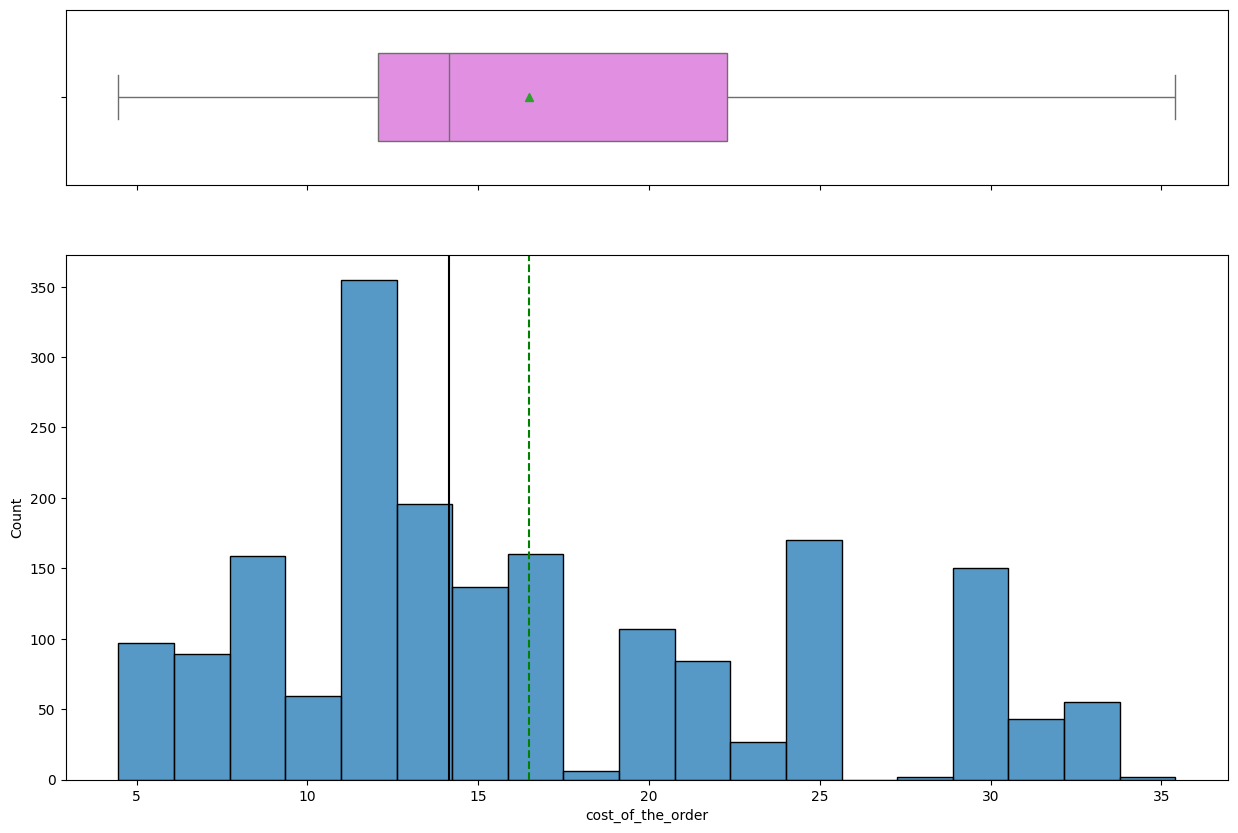

In [ ]:
histogram_boxplot(df.cost_of_the_order)

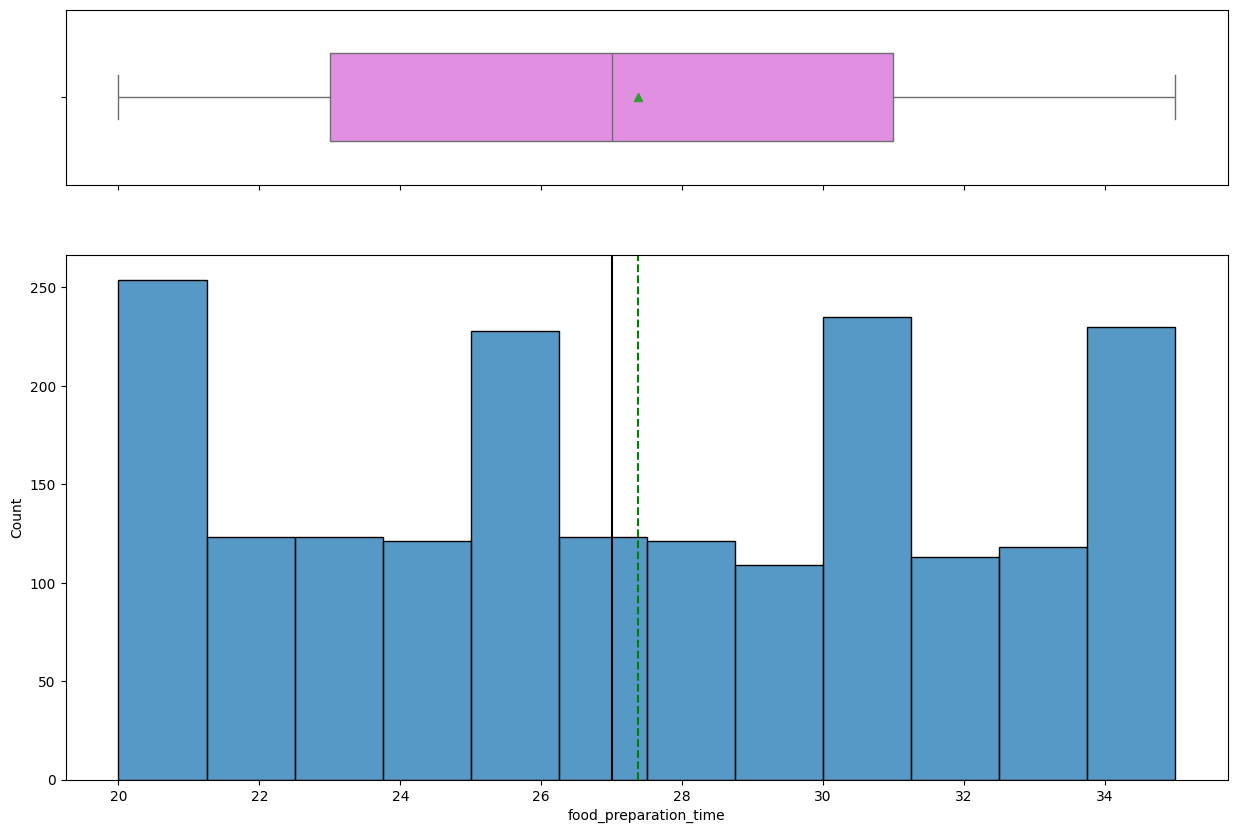

In [ ]:
histogram_boxplot(df.food_preparation_time)

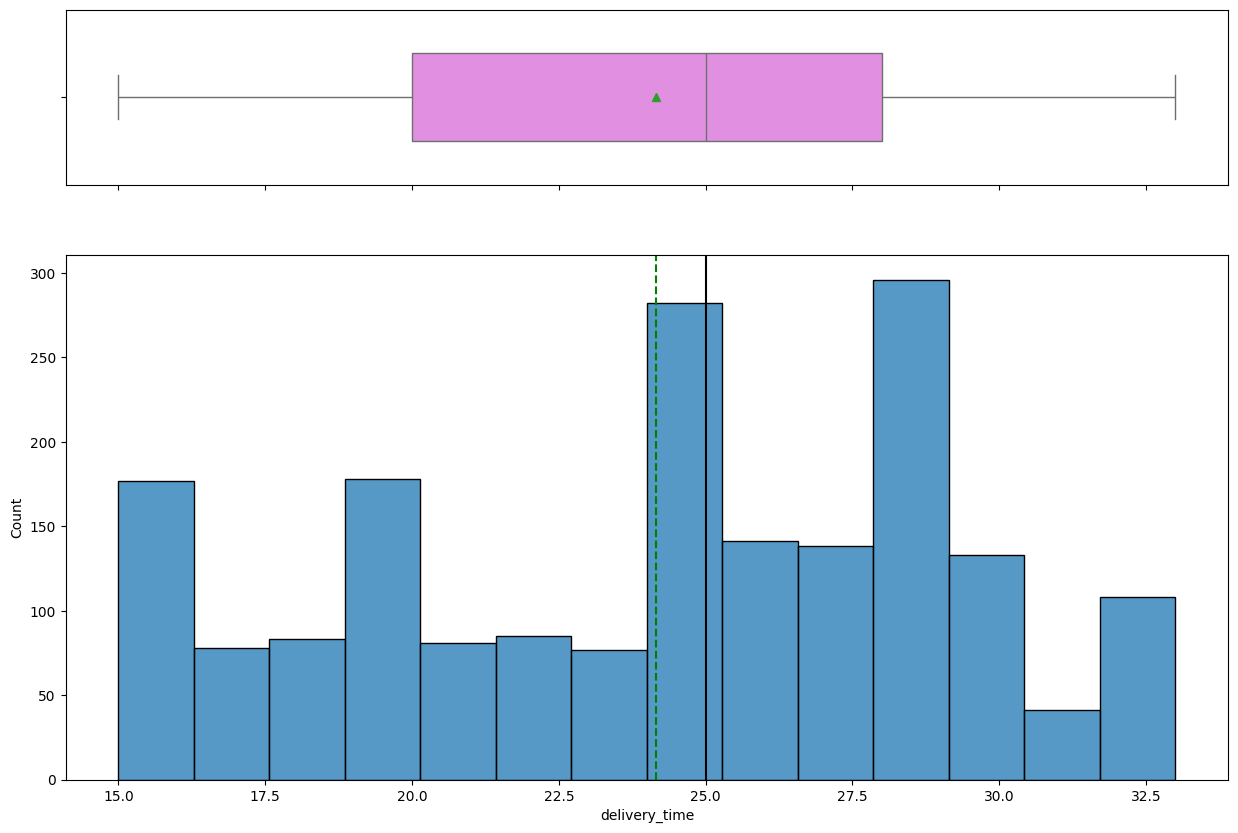

In [ ]:
histogram_boxplot(df.delivery_time)

**1. Cost of the Order Interpretation**

Right-Skewed Distribution: The mean (green dashed line) is higher than the median (black solid line), indicating that a few high-value orders are pulling the average up.

Core Pricing Tier: The highest density of orders occurs between $10 and $15. This is the sweet spot for volume.

Recommendation: Implement "Bundle Deals" at the $12–$15 dollar range. Since this is your highest conversion zone, creating exclusive FoodHub bundles at this price point can maximize order frequency from your largest customer segment.

**2. Delivery Time Interpretation**

Bimodal/Uniform Tendency: The delivery time distribution is relatively flat with peaks near 24 and 28 minutes. There is no single "typical" delivery time, but rather a wide spread between 15 and 33 minutes.

Efficiency Metric: The median delivery time is approximately 25 minutes. The lack of extreme outliers suggests the delivery network is stable but has room for optimization in consistency.

Recommendation: Dynamic Driver Incentives. To tighten the distribution (making delivery times more predictable), the company should offer small "efficiency bonuses" for drivers in high-traffic zones who maintain a sub-22-minute delivery window during peak hours.

**3. Combined Business Insight**

The "Convenience" Value Prop: Most orders are low-to-mid cost and delivered in under 30 minutes. This suggests FoodHub is currently positioned as a convenience-first platform rather than a premium dining service.

Recommendation: Targeted Upselling. Since delivery times are fairly consistent even for cheaper orders, the company could introduce a "Premium Delivery" tier for high-value orders (e.g., >$30) to increase the average order value while maintaining the same operational speed.

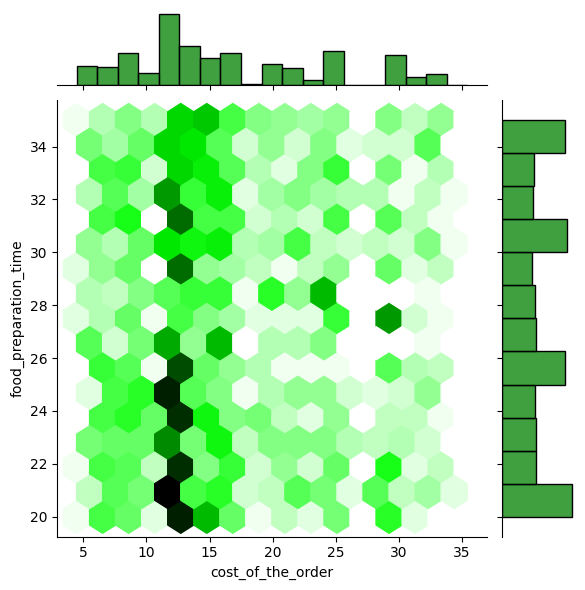

In [ ]:
#EDA : Multivariate using jointplot
# check for Cost vs Prep time
sns.jointplot(data=df, x='cost_of_the_order', y='food_preparation_time', kind="hex", color="green")
plt.show()

The jointplot chart confirms the following:
- There's no correlation between Cost of the order and Food Preparation Time. Paying more for a meal doesn't guarantee faster preparation & vice versa.
- Standard food preparation for resturants in this data set is between 20 to 35 minutes.
- The darkest spots reflect where the highest volume of orders occurs, between $10 - $15 regardless of how long it takes to make the food. The top histogram shows that the $12 order drives the most volume.

**Recommendation for the company using inference from the chart:**  
1. **Create a `$12` Value Tier**: The data is highly concentrated between `$10` and $15. The company should partner with restaurants to offer "FoodHub Exclusive" bundles at this price point to maximize conversion from its largest customer segment.

2. **Automate Driver Dispatching:** The chart shows a very predictable floor
prep time (20 minutes) and a ceiling (35 minutes). The system should wait at least 15–20 minutes after an order is placed before alerting a driver to ensure they aren't waiting idly at the restaurant.

3. **Recruit "Premium" Mid-Tier Restaurants:**  There are visible gaps (white space) in the $25–$30 price range. The company should target restaurants that offer higher-ticket items to fill these gaps and increase the overall Average Order Value beyond the current $12–$15 cluster.

<Axes: xlabel='day_of_the_week', ylabel='cuisine_type'>

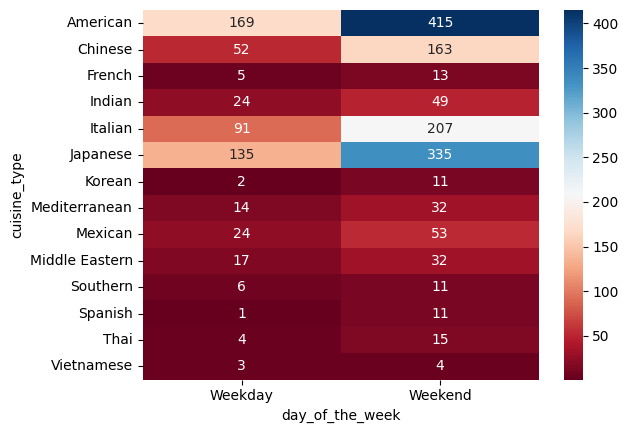

In [ ]:
#Using a HeatMap to understand order volume
pivot_count = df.pivot_table(index='cuisine_type', columns='day_of_the_week', values='order_id', aggfunc='count')
sns.heatmap(pivot_count, annot=True, fmt='d', cmap='RdBu')

- The sharp contrast between red & blue shows that traffic is more concentrated in only four cuisines-American, Japanese, Italian & Chinese. With American & Japanese commanding the highest.
- American & Japanese remains the dominant choice both in extreme weekend orders & high volume weekday orders.
- while Italian & Chinese food notably doubles its volume on Weekends all other cuisines remain very small niche segement

**Recommendation  to the company based on HeatMap chart above:**

1. **Optimize Weekend Logistics**: Focus driver recruitment and scheduling primarily on the Friday–Sunday window, as the massive volume surge in American and Japanese orders (over 700 combined) suggests this is where delivery delays and service bottlenecks are most likely to occur.

2. **Leverage Top-Tier Partnerships:** Strengthen relationships and run targeted marketing campaigns with high-volume American and Japanese restaurants, as these two cuisines are the platform’s "anchor" tenants that drive the majority of consistent weekday and weekend traffic.

3. **Grow the "Mid-Tier" Cuisines:** Implement promotional "Weekday Specials" for Italian and Chinese cuisines to convert their strong weekend interest into more consistent weekday revenue, helping to balance the platform's workload across the entire week.